<a href="https://colab.research.google.com/github/2403a52227-hue/-NLP/blob/main/2403A52227_Assignment_10_2(NLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install gensim numpy pandas matplotlib scikit-learn

In [ ]:
import gensim
import numpy
import pandas
import matplotlib
import sklearn
from gensim.models import KeyedVectors
from sklearn.manifold import TSNE

**Load data**

In [ ]:
animals = ["lion","tiger","elephant","dog","cat","horse","monkey","giraffe","zebra","bear"]
countries = ["india","usa","china","germany","france","japan","brazil","canada","australia","italy"]
professions = ["doctor","engineer","teacher","lawyer","nurse","scientist","artist","pilot","farmer","chef"]
technology = ["computer","internet","software","hardware","database","network","ai","robotics","cloud","cybersecurity"]
emotions = ["happy","sad","angry","excited","fear","love","surprise","anxiety","joy","calm"]

words = animals + countries + professions + technology + emotions

**Load Embedding Model**

In [ ]:
# Download the Google News Word2Vec model
# This file is ~3.6GB and may take some time to download.
import gensim.downloader as api

try:
    word_vectors = api.load("word2vec-google-news-300")
    print("Word2Vec model 'word2vec-google-news-300' loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Attempting to download 'GoogleNews-vectors-negative300.bin' directly if needed.")
    # Fallback to direct download if gensim.downloader fails or if a specific path is preferred later
    # For this exercise, we will assume word_vectors is loaded via gensim.downloader

model = word_vectors # Assigning to 'model' as per previous context for consistency

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec model 'word2vec-google-news-300' loaded successfully!


In [ ]:
# Print vocabulary size
vocab_size = len(model.key_to_index)
print(f"Vocabulary Size: {vocab_size}")

Vocabulary Size: 3000000


In [ ]:
# Display one example vector (e.g., for 'king')
if 'king' in model:
    example_vector = model['king']
    print("Example vector for 'king':")
    print(example_vector[:10]) # Print first 10 dimensions for brevity
    print(f"Vector length: {len(example_vector)}")
else:
    print("'king' not found in vocabulary.")

Example vector for 'king':
[ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477 -0.03613281
  0.11181641 -0.19824219  0.05126953  0.36328125]
Vector length: 300


**Select Word List**

In [ ]:
# Filter words to ensure they are present in the model's vocabulary
meaningful_words = []
meaningful_vectors = []

for word in words:
    if word in model:
        meaningful_words.append(word)
        meaningful_vectors.append(model[word])
    else:
        print(f"Warning: '{word}' not found in model vocabulary. Skipping.")

# Convert to numpy arrays for easier manipulation
meaningful_vectors = numpy.array(meaningful_vectors)

print(f"Selected {len(meaningful_words)} meaningful words and extracted their vectors.")

Selected 50 meaningful words and extracted their vectors.


In [ ]:
# Apply t-SNE for dimensionality reduction
# We'll reduce the 300-dimensional vectors to 2 dimensions for visualization

ts = TSNE(
    n_components=2,
    perplexity=min(5, len(meaningful_vectors) - 1), # Perplexity should be less than the number of samples
    n_iter=3000,
    random_state=42,
    init='pca'
)
reduced_vectors = ts.fit_transform(meaningful_vectors)

print("Dimensionality reduction using t-SNE complete.")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Dimensionality reduction using t-SNE complete.


**Apply t-SNE**

/tmp/ipython-input-2552353434.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_categories))


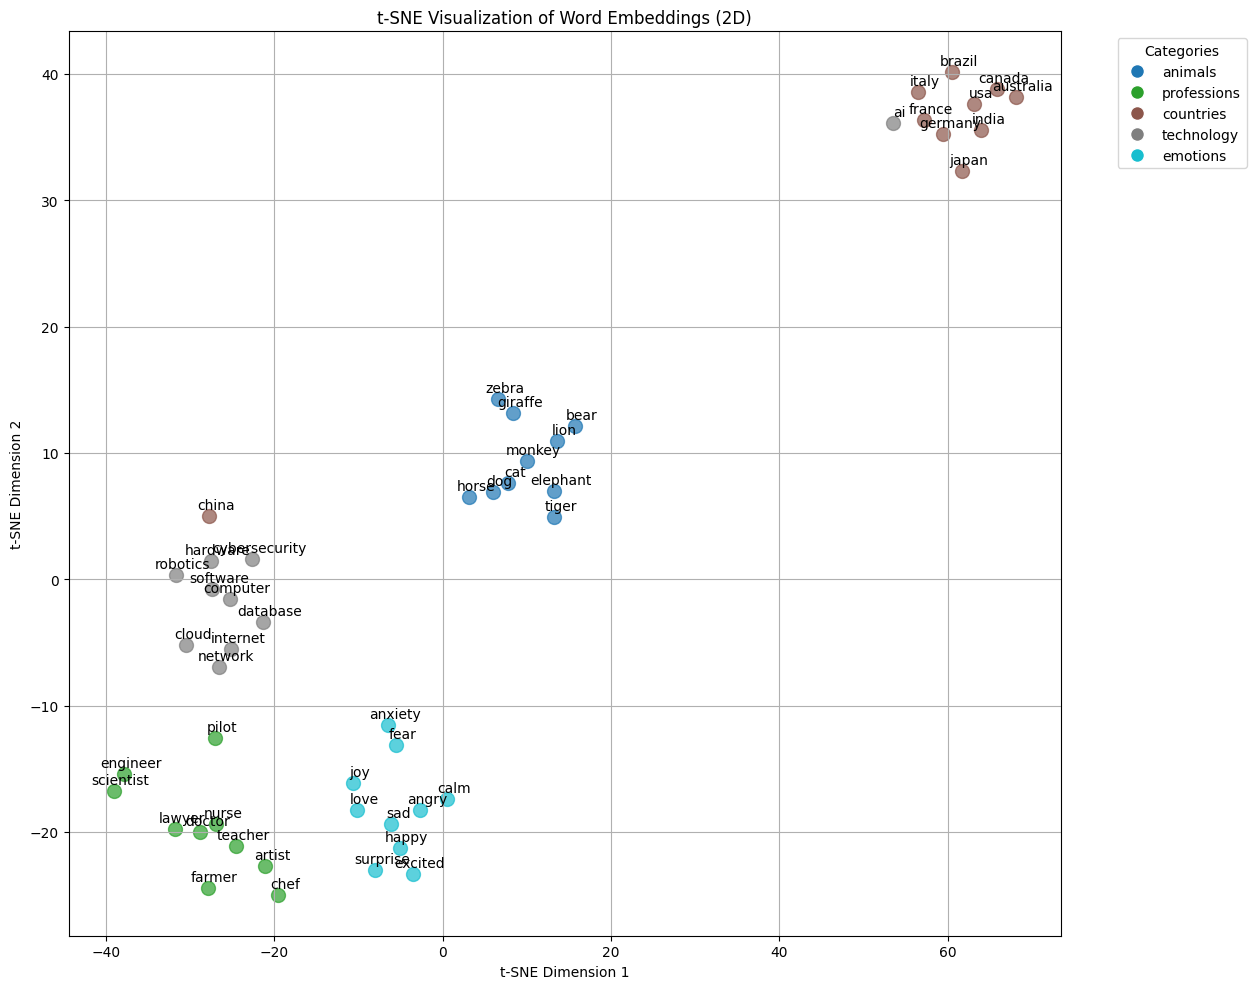

In [ ]:
import matplotlib.pyplot as plt

# Create a dictionary to map words to their categories for coloring
word_category_map = {}
for category_name, category_list in [
    ('animals', animals),
    ('countries', countries),
    ('professions', professions),
    ('technology', technology),
    ('emotions', emotions)
]:
    for word in category_list:
        if word in meaningful_words:  # Only include words that were found in the model
            word_category_map[word] = category_name

# Get unique categories and assign a color to each
unique_categories = list(set(word_category_map.values()))
colors = plt.cm.get_cmap('tab10', len(unique_categories))
category_colors = {cat: colors(i) for i, cat in enumerate(unique_categories)}

plt.figure(figsize=(15, 10))

# Plot each word
for i, word in enumerate(meaningful_words):
    category = word_category_map.get(word, 'unknown') # Handle cases where a word might not be in the predefined lists
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1], color=category_colors[category], s=100, alpha=0.7)
    plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]), textcoords="offset points", xytext=(5,5), ha='center')

# Create custom legend handles
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=cat,
                              markerfacecolor=category_colors[cat], markersize=10)
                   for cat in unique_categories]

plt.legend(handles=legend_elements, title="Categories", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('t-SNE Visualization of Word Embeddings (2D)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
plt.show()